so somehow even with a nn of one layer which is basically a linear regression model the problem is solved 

maybe the data is lineararly seperaable somehow

or giving the same accuray as it would with a much larger neural net with more neurons 

guess -> just by the image size class can be estimated 



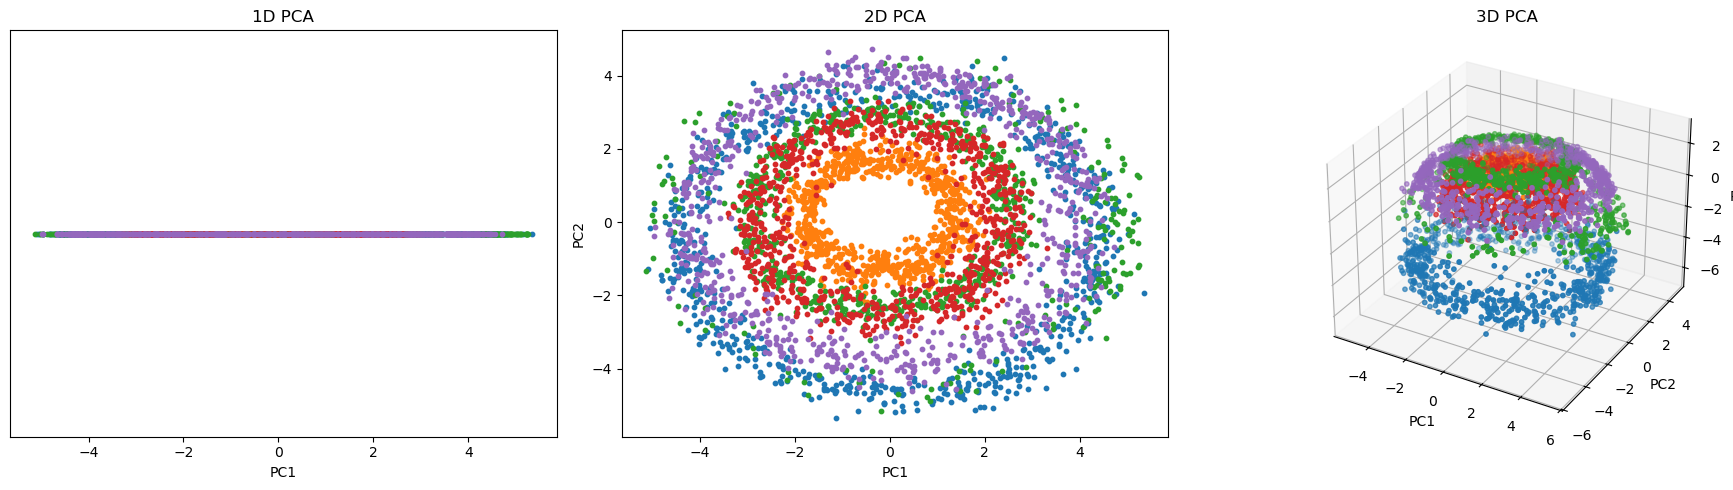

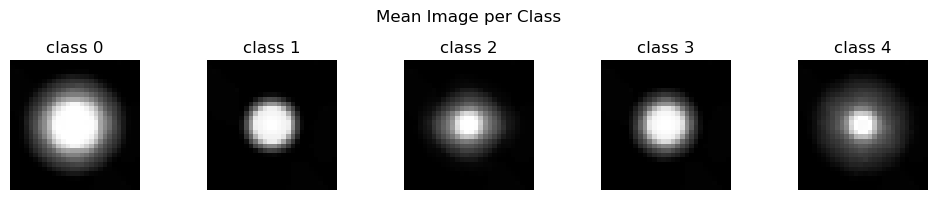

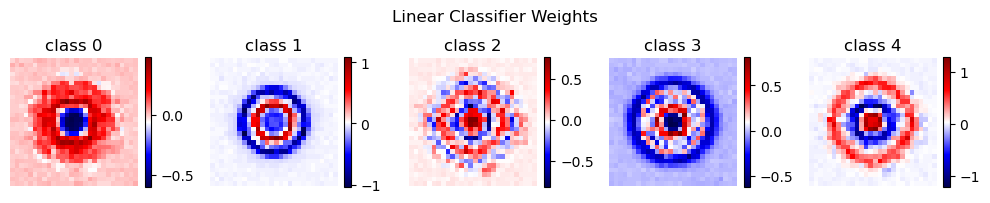

In [2]:

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# PATHS
# =====================================================
TRAIN_PATH = "/Users/satviksingh/Documents/repos/satvik_VII/working_directory/neural net problems/Train"

IMG_SIZE = 28
NUM_CLASSES = 5

# =====================================================
# DATA LOADING
# =====================================================
def load_dataset(root_dir):
    X, Y = [], []

    class_names = sorted(
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    )

    for label, cname in enumerate(class_names):
        class_path = os.path.join(root_dir, cname)

        for file in os.listdir(class_path):
            if file.lower().endswith(".png"):
                img = Image.open(os.path.join(class_path, file)).convert("L")
                img = img.resize((IMG_SIZE, IMG_SIZE))
                img = np.array(img).reshape(-1) / 255.0

                X.append(img)

                y = np.zeros(NUM_CLASSES)
                y[label] = 1
                Y.append(y)

    return np.array(X).T, np.array(Y).T

# =====================================================
# PCA (SVD Based - Stable)
# =====================================================
def compute_pca(X, n_components=3):
    Xc = X - np.mean(X, axis=1, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    W = U[:, :n_components]
    return W.T @ Xc

def plot_pca_all(X, Y):
    labels = np.argmax(Y, axis=0)
    X_pca = compute_pca(X, n_components=3)

    fig = plt.figure(figsize=(18, 5))

    # --------------------------
    # 1D PCA
    # --------------------------
    ax1 = fig.add_subplot(131)
    for c in range(NUM_CLASSES):
        idx = labels == c
        ax1.scatter(
            X_pca[0, idx],
            np.zeros(np.sum(idx)),
            s=10,
            label=f"class {c}"
        )

    ax1.set_title("1D PCA")
    ax1.set_xlabel("PC1")
    ax1.set_yticks([])

    # --------------------------
    # 2D PCA
    # --------------------------
    ax2 = fig.add_subplot(132)
    for c in range(NUM_CLASSES):
        idx = labels == c
        ax2.scatter(
            X_pca[0, idx],
            X_pca[1, idx],
            s=10,
            label=f"class {c}"
        )

    ax2.set_title("2D PCA")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")

    # --------------------------
    # 3D PCA
    # --------------------------
    ax3 = fig.add_subplot(133, projection='3d')
    for c in range(NUM_CLASSES):
        idx = labels == c
        ax3.scatter(
            X_pca[0, idx],
            X_pca[1, idx],
            X_pca[2, idx],
            s=10,
            label=f"class {c}"
        )

    ax3.set_title("3D PCA")
    ax3.set_xlabel("PC1")
    ax3.set_ylabel("PC2")
    ax3.set_zlabel("PC3")

    plt.tight_layout()

# =====================================================
# CLASS MEAN IMAGES
# =====================================================
def plot_class_means(X, Y):
    labels = np.argmax(Y, axis=0)

    plt.figure(figsize=(10, 2))
    for c in range(NUM_CLASSES):
        Xc = X[:, labels == c]
        mean_img = np.mean(Xc, axis=1).reshape(IMG_SIZE, IMG_SIZE)

        plt.subplot(1, NUM_CLASSES, c + 1)
        plt.imshow(mean_img, cmap="gray")
        plt.axis("off")
        plt.title(f"class {c}")

    plt.suptitle("Mean Image per Class")
    plt.tight_layout()

# =====================================================
# LINEAR CLASSIFIER
# =====================================================
def softmax(Z):
    Z -= np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def train_linear(X, Y, lr=0.2, epochs=3000):
    W = np.random.randn(NUM_CLASSES, X.shape[0]) * 0.01
    b = np.zeros((NUM_CLASSES, 1))

    for _ in range(epochs):
        Z = W @ X + b
        A = softmax(Z)

        dZ = A - Y
        W -= lr * (dZ @ X.T) / X.shape[1]
        b -= lr * np.mean(dZ, axis=1, keepdims=True)

    return W, b

# =====================================================
# VISUALIZE LINEAR WEIGHTS
# =====================================================
def plot_linear_weights(W):
    plt.figure(figsize=(10, 2))
    for c in range(NUM_CLASSES):
        plt.subplot(1, NUM_CLASSES, c + 1)
        plt.imshow(W[c].reshape(IMG_SIZE, IMG_SIZE), cmap="seismic")
        plt.colorbar(fraction=0.046)
        plt.axis("off")
        plt.title(f"class {c}")

    plt.suptitle("Linear Classifier Weights")
    plt.tight_layout()

# =====================================================
# MAIN
# =====================================================
if __name__ == "__main__":
    X_train, Y_train = load_dataset(TRAIN_PATH)

    # PCA Visualizations
    plot_pca_all(X_train, Y_train)

    # Class Mean Images
    plot_class_means(X_train, Y_train)

    # Train Linear Classifier
    W, b = train_linear(X_train, Y_train)

    # Visualize Weights
    plot_linear_weights(W)

    # Single blocking call
    plt.show()

In [3]:
import os
import numpy as np
from PIL import Image

TRAIN_PATH = "/Users/satviksingh/Documents/repos/satvik_VII/working_directory/neural net problems/Train"
TEST_PATH  = "/Users/satviksingh/Documents/repos/satvik_VII/working_directory/neural net problems/Test"

IMG_SIZE = 28
NUM_CLASSES = 5
LR = 0.15
EPOCHS = 15000

def load_dataset(root_dir):
    X, Y = [], []
    class_names = sorted(d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d)))

    for label, cname in enumerate(class_names):
        for file in os.listdir(os.path.join(root_dir, cname)):
            if file.lower().endswith(".png"):
                img = Image.open(os.path.join(root_dir, cname, file)).convert("L")
                img = np.array(img.resize((IMG_SIZE, IMG_SIZE))).reshape(-1) / 255.0
                X.append(img)

                y = np.zeros(NUM_CLASSES)
                y[label] = 1
                Y.append(y)

    return np.array(X).T, np.array(Y).T

def softmax(Z):
    Z -= np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def init_params():
    W = np.random.randn(NUM_CLASSES, 784) * 0.01
    b = np.zeros((NUM_CLASSES, 1))
    return W, b

def forward(X, W, b):
    Z = W @ X + b
    A = softmax(Z)
    return A, X

def backward(cache, Y, A):
    X = cache
    m = X.shape[1]
    dZ = A - Y
    dW = dZ @ X.T / m
    db = np.sum(dZ, axis=1, keepdims=True) / m
    return dW, db

def train(X, Y):
    W, b = init_params()

    for epoch in range(EPOCHS):
        A, cache = forward(X, W, b)
        loss = -np.mean(np.sum(Y * np.log(A + 1e-8), axis=0))
        dW, db = backward(cache, Y, A)

        W -= LR * dW
        b -= LR * db

        if epoch % 500 == 0:
            print(f"epoch {epoch} | loss {loss:.4f}")

    return W, b

def accuracy(X, Y, W, b):
    A, _ = forward(X, W, b)
    return np.mean(np.argmax(A, axis=0) == np.argmax(Y, axis=0))

X_train, Y_train = load_dataset(TRAIN_PATH)
X_test, Y_test   = load_dataset(TEST_PATH)

W, b = train(X_train, Y_train)

print("Train accuracy:", accuracy(X_train, Y_train, W, b))
print("Test accuracy :", accuracy(X_test, Y_test, W, b))


epoch 0 | loss 1.6296
epoch 500 | loss 0.2701
epoch 1000 | loss 0.2073
epoch 1500 | loss 0.1768
epoch 2000 | loss 0.1577
epoch 2500 | loss 0.1442
epoch 3000 | loss 0.1340
epoch 3500 | loss 0.1260
epoch 4000 | loss 0.1195
epoch 4500 | loss 0.1141
epoch 5000 | loss 0.1094
epoch 5500 | loss 0.1054
epoch 6000 | loss 0.1018
epoch 6500 | loss 0.0987
epoch 7000 | loss 0.0958
epoch 7500 | loss 0.0933
epoch 8000 | loss 0.0910
epoch 8500 | loss 0.0888
epoch 9000 | loss 0.0869
epoch 9500 | loss 0.0850
epoch 10000 | loss 0.0834
epoch 10500 | loss 0.0818
epoch 11000 | loss 0.0803
epoch 11500 | loss 0.0789
epoch 12000 | loss 0.0776
epoch 12500 | loss 0.0764
epoch 13000 | loss 0.0752
epoch 13500 | loss 0.0741
epoch 14000 | loss 0.0730
epoch 14500 | loss 0.0720
Train accuracy: 0.98375
Test accuracy : 0.955


In [4]:
# neural net for comparison 
# of architecture
'''Input (784)
   ↓
Hidden Layer (8 neurons, ReLU)
   ↓
Output Layer (5 neurons, Softmax)'''

import os
import numpy as np
from PIL import Image

# =====================================================
# CONFIG — CHANGE ONLY THESE TWO PATHS
# =====================================================
TRAIN_PATH = "/Users/satviksingh/Documents/repos/satvik_VII/working_directory/neural net problems/Train"
TEST_PATH  = "/Users/satviksingh/Documents/repos/satvik_VII/working_directory/neural net problems/Test"

IMG_SIZE = 28
NUM_CLASSES = 5
HIDDEN_UNITS = 8
LR = 0.1
EPOCHS = 10000

# =====================================================
# DATA LOADING
# =====================================================
def load_dataset(root_dir):
    X, Y = [], []

    class_names = sorted([
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ])

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(root_dir, class_name)

        for file in os.listdir(class_path):
            if file.lower().endswith(".png"):
                path = os.path.join(class_path, file)

                img = Image.open(path).convert("L")
                img = img.resize((IMG_SIZE, IMG_SIZE))
                img = np.array(img).reshape(-1) / 255.0

                X.append(img)

                y = np.zeros(NUM_CLASSES)
                y[label] = 1
                Y.append(y)

    X = np.array(X).T   # (784, m)
    Y = np.array(Y).T   # (5, m)
    return X, Y

# =====================================================
# ACTIVATIONS
# =====================================================
def relu(Z):
    return np.maximum(0, Z)

def relu_backward(dA, Z):
    dZ = dA.copy()
    dZ[Z <= 0] = 0
    return dZ

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

# =====================================================
# INITIALIZATION
# =====================================================
def init_params():
    W1 = np.random.randn(HIDDEN_UNITS, IMG_SIZE * IMG_SIZE) * 0.01
    b1 = np.zeros((HIDDEN_UNITS, 1))
    W2 = np.random.randn(NUM_CLASSES, HIDDEN_UNITS) * 0.01
    b2 = np.zeros((NUM_CLASSES, 1))
    return W1, b1, W2, b2

# =====================================================
# FORWARD
# =====================================================
def forward(X, W1, b1, W2, b2):
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = softmax(Z2)
    cache = (X, Z1, A1, Z2, A2)
    return A2, cache

# =====================================================
# LOSS
# =====================================================
def cross_entropy(A2, Y):
    m = Y.shape[1]
    return -np.sum(Y * np.log(A2 + 1e-8)) / m

# =====================================================
# BACKPROP
# =====================================================
def backward(cache, Y, W2):
    X, Z1, A1, Z2, A2 = cache
    m = X.shape[1]

    dZ2 = A2 - Y
    dW2 = (1/m) * dZ2 @ A1.T
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = W2.T @ dZ2
    dZ1 = relu_backward(dA1, Z1)
    dW1 = (1/m) * dZ1 @ X.T
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

# =====================================================
# UPDATE
# =====================================================
def update(W1, b1, W2, b2, dW1, db1, dW2, db2):
    W1 -= LR * dW1
    b1 -= LR * db1
    W2 -= LR * dW2
    b2 -= LR * db2
    return W1, b1, W2, b2

# =====================================================
# TRAIN
# =====================================================
def train(X, Y):
    W1, b1, W2, b2 = init_params()

    for epoch in range(EPOCHS):
        A2, cache = forward(X, W1, b1, W2, b2)
        loss = cross_entropy(A2, Y)
        dW1, db1, dW2, db2 = backward(cache, Y, W2)
        W1, b1, W2, b2 = update(W1, b1, W2, b2, dW1, db1, dW2, db2)

        if epoch % 100 == 0:
            print(f"epoch {epoch} | loss {loss:.4f}")

    return W1, b1, W2, b2

# =====================================================
# ACCURACY
# =====================================================
def accuracy(X, Y, W1, b1, W2, b2):
    A2, _ = forward(X, W1, b1, W2, b2)
    preds = np.argmax(A2, axis=0)
    labels = np.argmax(Y, axis=0)
    return np.mean(preds == labels)

# =====================================================
# MAIN
# =====================================================
if __name__ == "__main__":
    if not os.path.isdir(TRAIN_PATH):
        raise FileNotFoundError(TRAIN_PATH)
    if not os.path.isdir(TEST_PATH):
        raise FileNotFoundError(TEST_PATH)

    X_train, Y_train = load_dataset(TRAIN_PATH)
    X_test, Y_test = load_dataset(TEST_PATH)

    print("Train:", X_train.shape, Y_train.shape)
    print("Test :", X_test.shape, Y_test.shape)

    W1, b1, W2, b2 = train(X_train, Y_train)

    print("Train accuracy:", accuracy(X_train, Y_train, W1, b1, W2, b2))
    print("Test accuracy :", accuracy(X_test, Y_test, W1, b1, W2, b2))


Train: (784, 4000) (5, 4000)
Test : (784, 1000) (5, 1000)
epoch 0 | loss 1.6093
epoch 100 | loss 1.0255
epoch 200 | loss 0.4348
epoch 300 | loss 0.2669
epoch 400 | loss 0.2040
epoch 500 | loss 0.1709
epoch 600 | loss 0.1505
epoch 700 | loss 0.1367
epoch 800 | loss 0.1267
epoch 900 | loss 0.1190
epoch 1000 | loss 0.1127
epoch 1100 | loss 0.1073
epoch 1200 | loss 0.1027
epoch 1300 | loss 0.0986
epoch 1400 | loss 0.0949
epoch 1500 | loss 0.0915
epoch 1600 | loss 0.0884
epoch 1700 | loss 0.0855
epoch 1800 | loss 0.0829
epoch 1900 | loss 0.0804
epoch 2000 | loss 0.0780
epoch 2100 | loss 0.0758
epoch 2200 | loss 0.0737
epoch 2300 | loss 0.0717
epoch 2400 | loss 0.0699
epoch 2500 | loss 0.0681
epoch 2600 | loss 0.0664
epoch 2700 | loss 0.0648
epoch 2800 | loss 0.0633
epoch 2900 | loss 0.0619
epoch 3000 | loss 0.0605
epoch 3100 | loss 0.0592
epoch 3200 | loss 0.0579
epoch 3300 | loss 0.0567
epoch 3400 | loss 0.0556
epoch 3500 | loss 0.0545
epoch 3600 | loss 0.0535
epoch 3700 | loss 0.0525
epoc